
# 🌱 Análisis de Cambios de Vegetación con Sentinel-2 (La Palma, 2021)

Este notebook muestra cómo detectar **cambios de vegetación** antes y después de la **erupción volcánica de Cumbre Vieja (Islas Canarias, 2021)** utilizando datos **Sentinel-2 L2A** del programa **Copernicus**.

Aprenderás a:
1. Descargar imágenes Sentinel-2 mediante la API de Sentinel Hub.
2. Calcular el índice NDVI.
3. Visualizar el cambio de vegetación (ΔNDVI) entre dos fechas.



## 🧩 1. Instalación de dependencias

Primero instalá el paquete `sentinelhub`, que permite acceder a los datos del programa Copernicus directamente desde Python.


In [ ]:
# !pip install sentinelhub
# !pip install ipywidgets tqdm
# !jupyter nbextension enable --py widgetsnbextension


Enabling notebook extension jupyter-js-widgets/extension...
      - Validating: OK


## 🔑 2. Configuración de credenciales

Las imágenes se descargan desde **Copernicus Data Space Ecosystem (CDSE)**, la plataforma oficial y **gratuita** del programa Copernicus (Agencia Espacial Europea y Comisión Europea). La librería `sentinelhub` se conecta a su API para buscar y descargar imágenes Sentinel-2.

Para usarla necesitás dos datos: un **Client ID** y un **Client Secret**. Funcionan como un usuario y una contraseña para que tu código (no vos) se conecte a la API. Seguí estos pasos una sola vez.

### Paso A: Crear tu cuenta en Copernicus Data Space

1. Entrá a [https://dataspace.copernicus.eu](https://dataspace.copernicus.eu) y hacé clic en **Login** (arriba a la derecha).
2. En la pantalla de inicio de sesión, elegí **Register** para crear una cuenta nueva.
3. Completá el formulario (nombre, email, país, contraseña, etc.) y aceptá los términos.
4. Vas a recibir un **email de verificación**: abrilo y confirmá tu cuenta. Si no llega en unos minutos, revisá la carpeta de spam.

> Si ya tenés cuenta en Copernicus (por ejemplo, del Paso 1 del notebook de clase), usá esa misma y saltá al Paso B.

### Paso B: Generar el Client ID y el Client Secret

1. Entrá al **Sentinel Hub Dashboard de CDSE**: [https://shapps.dataspace.copernicus.eu/dashboard/](https://shapps.dataspace.copernicus.eu/dashboard/) e iniciá sesión con la cuenta del Paso A.
2. Abrí la pestaña **User Settings**.
3. Buscá la sección **OAuth clients** y hacé clic en **Create**.
4. Completá el formulario:
   - **Name**: un nombre que te sirva para reconocerlo, por ejemplo `taller-ndvi`.
   - **Expiry date**: elegí una fecha posterior al final del taller, o **Never expire**.
   - **No** marques la opción de *single-page application (SPA)*: no la necesitamos.
5. Hacé clic en **Create**.
6. ⚠️ **Copiá en ese momento el Client ID y el Client Secret** y guardalos en un lugar seguro (por ejemplo, un gestor de contraseñas). **El secret se muestra una sola vez.** Si lo perdés, no se puede recuperar: borrá ese cliente y creá otro.

### Paso C: Darle las credenciales al notebook

**Nunca escribas tus credenciales dentro del notebook.** Si lo compartís o lo subís a GitHub, cualquiera podría usarlas. Tenés dos opciones:

**Opción 1: variables de entorno (recomendada).** Las variables de entorno se definen en una terminal del sistema (en macOS, la app *Terminal*; en Windows, *PowerShell*), **no en una celda del notebook**. El programa que abras después desde esa misma terminal las recibe.

1. Abrí una terminal y andá a la carpeta del taller:
   ```bash
   cd ruta/a/la/carpeta/del/taller
   ```
2. Si usás un entorno de Python (conda, venv), activalo. Por ejemplo, con conda:
   ```bash
   conda activate nombre-de-tu-entorno
   ```
3. Definí las credenciales:
   - macOS / Linux:
     ```bash
     export SH_CLIENT_ID="tu-client-id"
     export SH_CLIENT_SECRET="tu-client-secret"
     ```
   - Windows (PowerShell):
     ```powershell
     $env:SH_CLIENT_ID="tu-client-id"
     $env:SH_CLIENT_SECRET="tu-client-secret"
     ```
4. Desde **esa misma terminal**, abrí el programa con el que trabajás:
   - **JupyterLab**: `jupyter lab`
   - **Jupyter Notebook**: `jupyter notebook`
   - **VS Code**: `code .` (antes cerrá VS Code por completo, con Cmd + Q en macOS o *File → Exit* en Windows; si ya estaba abierto, no recibe las variables).

   Si aparece `command not found`, el programa no está instalado en ese entorno o el entorno no está activado (paso 2).

Las variables duran mientras esa terminal esté abierta: podés reiniciar el kernel sin perderlas. Si cerrás la terminal, la próxima vez repetí los pasos 1 a 4.

**Opción 2: escribirlas cuando el notebook las pida.** Si no definiste las variables (por ejemplo, en Google Colab), la celda siguiente te va a pedir el Client ID y el Client Secret en un cuadro de texto. Lo que escribas no se muestra ni se guarda en el notebook. Vas a tener que volver a escribirlas cada vez que reinicies el kernel.

### Paso D: Comprobar que funcionan

Ejecutá la celda siguiente. Al final verifica las credenciales contra Copernicus:

- ✅ `Credenciales válidas` → listo, seguí con la sección 3.
- ❌ `Credenciales inválidas` → revisá que hayas copiado el ID y el secret completos y sin espacios, y que el cliente no haya vencido. Si el secret se perdió, creá un cliente nuevo (Paso B).

In [ ]:
import os
from getpass import getpass
from sentinelhub import SHConfig, DataCollection, SentinelHubSession

# Las credenciales se leen de variables de entorno; si no existen, se piden por pantalla.
config = SHConfig()
config.sh_client_id = os.environ.get("SH_CLIENT_ID") or getpass("Client ID: ")
config.sh_client_secret = os.environ.get("SH_CLIENT_SECRET") or getpass("Client Secret: ")

# Servidores de Copernicus Data Space Ecosystem (CDSE)
config.sh_base_url = "https://sh.dataspace.copernicus.eu"
config.sh_token_url = "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token"

# Colección Sentinel-2 L2A servida desde CDSE (se usa en el catálogo y en las descargas)
S2_L2A = DataCollection.define_from(
    DataCollection.SENTINEL2_L2A, "SENTINEL2_L2A_CDSE", service_url=config.sh_base_url
)

# Comprobar las credenciales pidiendo un token
try:
    SentinelHubSession(config=config)
    print("✅ Credenciales válidas")
except Exception as e:
    print("❌ Credenciales inválidas:", e)


## 🌋 3. Definir la zona de estudio: La Palma (Cumbre Vieja)

Seleccionamos un área pequeña alrededor del cono volcánico, donde el contraste antes y después de la erupción es muy marcado.

La búsqueda elige, para cada período, la imagen con menos nubes. Las fechas elegidas se guardan en `data/fechas.json`: si volvés a ejecutar el notebook, se leen de ese archivo en lugar de consultar el catálogo otra vez. Para repetir la búsqueda, borrá ese archivo.


In [2]:
import json
from pathlib import Path
from sentinelhub import BBox, CRS, SentinelHubCatalog, DataCollection

# 🗺️ Área: mitad sur de La Palma, incluyendo coladas hacia la costa
bbox = BBox(
    bbox=[-18.00, 28.45, -17.75, 28.75],
    crs=CRS.WGS84
)

# ⚙️ Función para buscar la mejor imagen (menor cobertura nubosa)
catalog = SentinelHubCatalog(config=config)

def find_best_image(bbox, time_interval):
    search_iterator = catalog.search(
        S2_L2A,
        bbox=bbox,
        time=time_interval,
        fields={"include": ["id", "properties.datetime", "properties.eo:cloud_cover"], "exclude": []},
        limit=50
    )
    results = list(search_iterator)
    if not results:
        raise ValueError(f"No se encontraron imágenes entre {time_interval}")
    
    # Ordenar por menor porcentaje de nubes
    results.sort(key=lambda x: x["properties"]["eo:cloud_cover"])
    best = results[0]
    print(f"🛰️ Imagen seleccionada entre {time_interval}:")
    print("Fecha:", best["properties"]["datetime"])
    print("Cobertura nubosa:", best["properties"]["eo:cloud_cover"], "%")
    return best["properties"]["datetime"][:10]  # YYYY-MM-DD

# 💾 Las fechas elegidas se guardan en data/fechas.json para no repetir la búsqueda
FECHAS_PATH = Path("./data/fechas.json")

def cached_best_image(bbox, time_interval):
    fechas = json.loads(FECHAS_PATH.read_text()) if FECHAS_PATH.exists() else {}
    key = f"{bbox.min_x},{bbox.min_y},{bbox.max_x},{bbox.max_y}|{time_interval[0]}|{time_interval[1]}"
    if key in fechas:
        print(f"💾 {time_interval}: {fechas[key]} (leída de {FECHAS_PATH})")
    else:
        fechas[key] = find_best_image(bbox, time_interval)
        FECHAS_PATH.parent.mkdir(parents=True, exist_ok=True)
        FECHAS_PATH.write_text(json.dumps(fechas, indent=2))
    return fechas[key]

# 🔍 Buscar mejores imágenes antes y después de la erupción
best_before = cached_best_image(bbox, ("2021-08-01", "2021-08-25"))  # vegetación sana
best_after  = cached_best_image(bbox, ("2021-12-10", "2021-12-30"))  # post-erupción

# ⏰ Asignar fechas seleccionadas automáticamente
time_before = (best_before, best_before)
time_after  = (best_after, best_after)

print("\n✅ Fechas finales seleccionadas:")
print("Antes:", time_before)
print("Después:", time_after)

🛰️ Imagen seleccionada entre ('2021-08-01', '2021-08-25'):
Fecha: 2021-08-21T12:03:46Z
Cobertura nubosa: 0.0 %
🛰️ Imagen seleccionada entre ('2021-12-10', '2021-12-30'):
Fecha: 2021-12-14T12:03:34Z
Cobertura nubosa: 0.29 %

✅ Fechas finales seleccionadas:
Antes: ('2021-08-21', '2021-08-21')
Después: ('2021-12-14', '2021-12-14')



## 🛰️ 4. Descarga de imágenes Sentinel-2 L2A

Descargamos las bandas necesarias para NDVI:
- **B04 (Rojo)**  
- **B08 (Infrarrojo cercano)**

La resolución será de **10 m/píxel**.


In [3]:
from sentinelhub import (
    SentinelHubRequest, MimeType, DataCollection, bbox_to_dimensions
)
import numpy as np
import matplotlib.pyplot as plt
import os

# Crear carpeta de salida si no existe
os.makedirs("./data", exist_ok=True)

resolution = 30  # metros por píxel
size = bbox_to_dimensions(bbox, resolution=resolution)

def get_image(time_interval):
    request = SentinelHubRequest(
        data_folder="./data",
        evalscript="""
        //VERSION=3
        function setup() {
          return {
            input: ["B04", "B08"],
            output: { bands: 2, sampleType: "FLOAT32" }
          };
        }
        function evaluatePixel(sample) {
          return [sample.B04, sample.B08];
        }
        """,
        input_data=[
            SentinelHubRequest.input_data(
                data_collection=S2_L2A,
                time_interval=time_interval,
                mosaicking_order='leastCC'  # ✅ preferir menos nubes
            )
        ],
        responses=[SentinelHubRequest.output_response("default", MimeType.TIFF)],
        bbox=bbox,
        size=size,
        config=config
    )
    return request.get_data(save_data=True)[0]

# Descarga automática usando las mejores fechas detectadas
img_before = get_image(time_before)
img_after  = get_image(time_after)

b4_before, b8_before = img_before[..., 0], img_before[..., 1]
b4_after,  b8_after  = img_after[..., 0],  img_after[..., 1]


## 🌿 6. Cálculo del NDVI y del ΔNDVI

El **NDVI** (Normalized Difference Vegetation Index) se calcula como:

\[ NDVI = \frac{NIR - RED}{NIR + RED} \]

El cambio en vegetación se obtiene como:

\[ \Delta NDVI = NDVI_{después} - NDVI_{antes} \]


In [4]:

def ndvi(b8, b4):
    return (b8 - b4) / (b8 + b4 + 1e-6)

ndvi_before = ndvi(b8_before, b4_before)
ndvi_after  = ndvi(b8_after,  b4_after)
delta_ndvi  = ndvi_after - ndvi_before



## 🖼️ 7. Visualización de los resultados

Mostramos los mapas de NDVI antes, después y el cambio ΔNDVI.


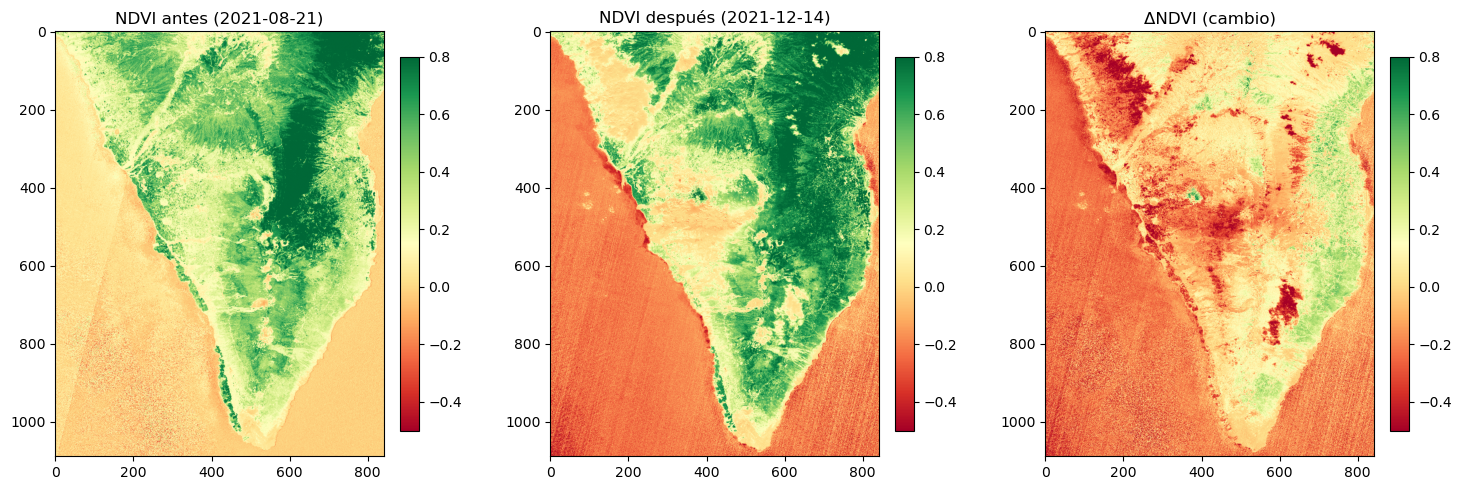

In [5]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

titles = [
    f"NDVI antes ({time_before[0]})",
    f"NDVI después ({time_after[0]})",
    "ΔNDVI (cambio)"
]

for ax, img, title in zip(axs, [ndvi_before, ndvi_after, delta_ndvi], titles):
    im = ax.imshow(img, cmap='RdYlGn', vmin=-0.5, vmax=0.8)
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


## 🧭 8. Interpretación

- Los tonos **verdes** indican vegetación sana.  
- Los **rojos o marrones** reflejan pérdida de cobertura vegetal.  
- En el mapa de **ΔNDVI**, los valores **negativos intensos** marcan zonas afectadas por lava y ceniza tras la erupción.

Este análisis puede adaptarse fácilmente a otros eventos (incendios, sequías o deforestación) modificando las coordenadas y fechas.


## 9. Evolución

Una erupción en la dorsal volcánica Cumbre Vieja, que comprende la mitad sur de la isla española de La Palma en las Islas Canarias, tuvo lugar entre el 19 de septiembre y el 13 de diciembre de 2021.

In [6]:
from sentinelhub import BBox, CRS, SentinelHubCatalog, DataCollection

# 🗺️ Zona centrada en el cono y coladas (evita el mar)
bbox = BBox(
    bbox=[-17.93, 28.53, -17.80, 28.64],
    crs=CRS.WGS84
)

catalog = SentinelHubCatalog(config=config)

def find_best_image(bbox, time_interval):
    search_iterator = catalog.search(
        S2_L2A,
        bbox=bbox,
        time=time_interval,
        fields={"include": ["properties.datetime", "properties.eo:cloud_cover"], "exclude": []},
        limit=30
    )
    results = list(search_iterator)
    if not results:
        raise ValueError(f"No se encontraron imágenes entre {time_interval}")
    results.sort(key=lambda x: x["properties"]["eo:cloud_cover"])
    best = results[0]["properties"]
    print(f"🛰️ {time_interval}: {best['datetime']} (nubes: {best['eo:cloud_cover']}%)")
    return best["datetime"][:10]

# 🔍 Buscar fechas en ventanas cortas (mitad de cada mes)
best_jul = cached_best_image(bbox, ("2021-07-10", "2021-07-20"))
best_aug = cached_best_image(bbox, ("2021-08-10", "2021-08-20"))
best_sep = cached_best_image(bbox, ("2021-09-10", "2021-09-20"))
best_oct = cached_best_image(bbox, ("2021-10-10", "2021-10-20"))
best_nov = cached_best_image(bbox, ("2021-11-10", "2021-11-20"))
best_dec = cached_best_image(bbox, ("2021-12-10", "2021-12-20"))
best_jan = cached_best_image(bbox, ("2022-01-10", "2022-01-20"))
best_feb = cached_best_image(bbox, ("2022-02-10", "2022-02-20"))

# --- Para el bloque NDVI ---
time_jul = (best_jul, best_jul)
time_aug = (best_aug, best_aug)
time_sep = (best_sep, best_sep)
time_oct = (best_oct, best_oct)
time_nov = (best_nov, best_nov)
time_dec = (best_dec, best_dec)
time_jan = (best_jan, best_jan)
time_feb = (best_feb, best_feb)

print("\n✅ Fechas seleccionadas:")
print("Jul:", best_jul)
print("Ago:", best_aug)
print("Sep:", best_sep)
print("Oct:", best_oct)
print("Nov:", best_nov)
print("Dic:", best_dec)
print("Ene:", best_jan)
print("Feb:", best_feb)

🛰️ ('2021-07-10', '2021-07-20'): 2021-07-17T12:03:46Z (nubes: 1.01%)
🛰️ ('2021-08-10', '2021-08-20'): 2021-08-16T12:03:43Z (nubes: 0.11%)
🛰️ ('2021-09-10', '2021-09-20'): 2021-09-10T12:03:44Z (nubes: 0.79%)
🛰️ ('2021-10-10', '2021-10-20'): 2021-10-15T12:03:45Z (nubes: 2.97%)
🛰️ ('2021-11-10', '2021-11-20'): 2021-11-19T12:03:44Z (nubes: 0.46%)
🛰️ ('2021-12-10', '2021-12-20'): 2021-12-14T12:03:34Z (nubes: 0.29%)
🛰️ ('2022-01-10', '2022-01-20'): 2022-01-13T12:03:39Z (nubes: 0.04%)
🛰️ ('2022-02-10', '2022-02-20'): 2022-02-17T12:03:45Z (nubes: 0.0%)

✅ Fechas seleccionadas:
Jul: 2021-07-17
Ago: 2021-08-16
Sep: 2021-09-10
Oct: 2021-10-15
Nov: 2021-11-19
Dic: 2021-12-14
Ene: 2022-01-13
Feb: 2022-02-17


🛰️ Descargando imagen Jul...
🛰️ Descargando imagen Ago...
🛰️ Descargando imagen Sep...
🛰️ Descargando imagen Oct...
🛰️ Descargando imagen Nov...
🛰️ Descargando imagen Dic...
🛰️ Descargando imagen Ene...
🛰️ Descargando imagen Feb...


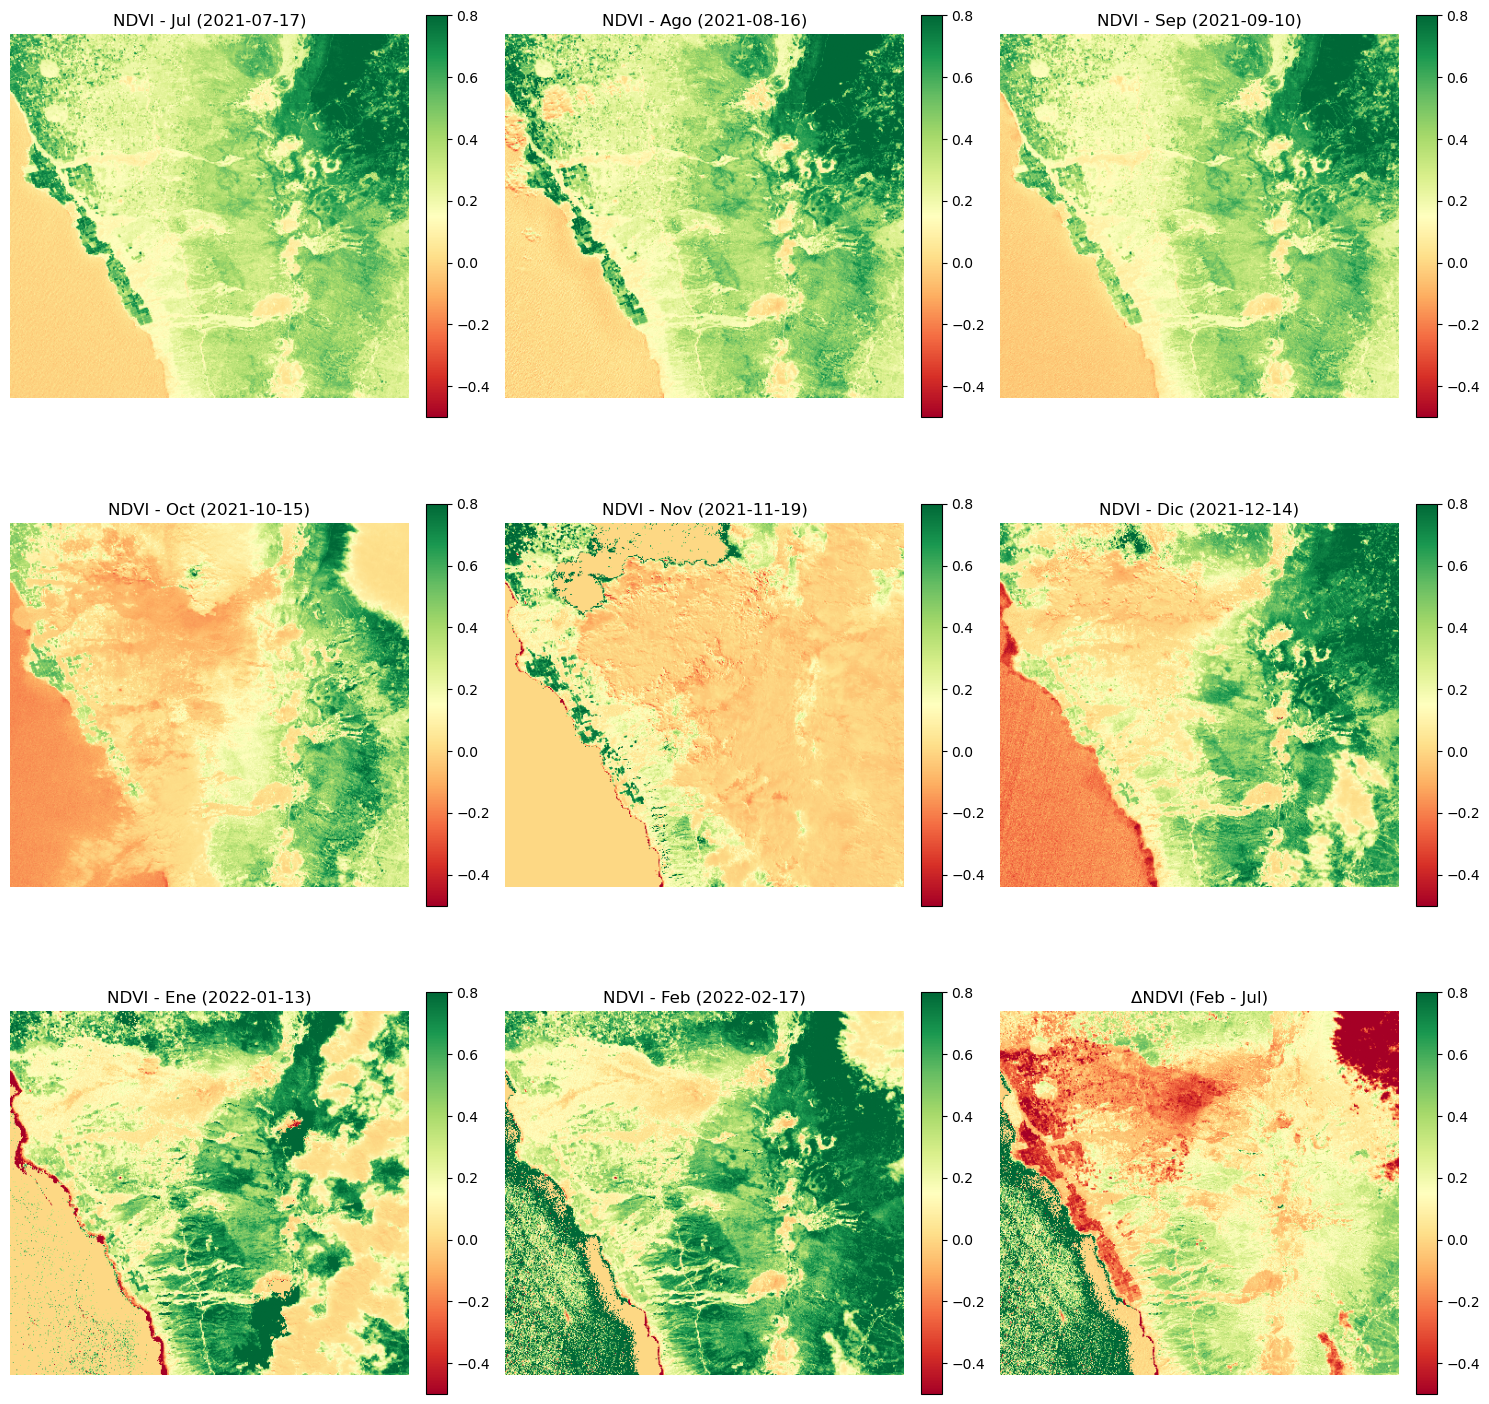

In [7]:
from sentinelhub import SentinelHubRequest, MimeType, DataCollection, bbox_to_dimensions
import numpy as np
import matplotlib.pyplot as plt
import os

# --- Crear carpeta de salida ---
os.makedirs("./data", exist_ok=True)

resolution = 30  # metros por píxel
size = bbox_to_dimensions(bbox, resolution=resolution)

# --- Función para obtener bandas rojo y NIR ---
def get_image(time_interval):
    request = SentinelHubRequest(
        data_folder="./data",
        evalscript="""
        //VERSION=3
        function setup() {
          return {
            input: ["B04", "B08"],
            output: { bands: 2, sampleType: "FLOAT32" }
          };
        }
        function evaluatePixel(sample) {
          return [sample.B04, sample.B08];
        }
        """,
        input_data=[
            SentinelHubRequest.input_data(
                data_collection=S2_L2A,
                time_interval=time_interval,
                mosaicking_order='leastCC'
            )
        ],
        responses=[SentinelHubRequest.output_response("default", MimeType.TIFF)],
        bbox=bbox,
        size=size,
        config=config
    )
    return request.get_data(save_data=True)[0]

# --- Descarga automática usando las mejores fechas detectadas ---
images = {}
for label, t in zip(
    ["Jul", "Ago", "Sep", "Oct", "Nov", "Dic", "Ene", "Feb"],
    [time_jul, time_aug, time_sep, time_oct, time_nov, time_dec, time_jan, time_feb]
):
    print(f"🛰️ Descargando imagen {label}...")
    img = get_image(t)
    b4, b8 = img[..., 0], img[..., 1]
    ndvi = (b8 - b4) / (b8 + b4 + 1e-6)
    images[label] = ndvi

# --- Calcular cambio entre julio y febrero ---
delta_ndvi = images["Feb"] - images["Jul"]

# --- Fechas exactas (para los títulos) ---
fechas = {
    "Jul": best_jul,
    "Ago": best_aug,
    "Sep": best_sep,
    "Oct": best_oct,
    "Nov": best_nov,
    "Dic": best_dec,
    "Ene": best_jan,
    "Feb": best_feb
}

# --- Plotear NDVI mensual + ΔNDVI ---
fig, axs = plt.subplots(3, 3, figsize=(15, 15))

titles = [
    f"NDVI - Jul ({fechas['Jul']})",
    f"NDVI - Ago ({fechas['Ago']})",
    f"NDVI - Sep ({fechas['Sep']})",
    f"NDVI - Oct ({fechas['Oct']})",
    f"NDVI - Nov ({fechas['Nov']})",
    f"NDVI - Dic ({fechas['Dic']})",
    f"NDVI - Ene ({fechas['Ene']})",
    f"NDVI - Feb ({fechas['Feb']})",
    "ΔNDVI (Feb - Jul)"
]

imgs = [
    images["Jul"],
    images["Ago"],
    images["Sep"],
    images["Oct"],
    images["Nov"],
    images["Dic"],
    images["Ene"],
    images["Feb"],
    delta_ndvi
]

for ax, img, title in zip(axs.ravel(), imgs, titles):
    im = ax.imshow(img, cmap="RdYlGn", vmin=-0.5, vmax=0.8)
    ax.set_title(title)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()